# Trader Performance vs Market Sentiment Analysis

**Author:** Abhisheka Lenin

## Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and Hyperliquid trader performance. The analysis explores how trader behavior and profitability vary under different market sentiment conditions.

In [15]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Make charts look nicer
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# Data Preparation

This section loads both datasets, checks for missing values and duplicate records, converts timestamps into a common format, and merges the trader data with the Bitcoin Fear & Greed Index using the date column.

In [16]:
# Load the datasets

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [17]:
# Information about the Fear & Greed dataset

print("Fear & Greed Dataset Information")
print("="*50)

sentiment.info()

Fear & Greed Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [18]:
# Information about the Trader dataset

print("Trader Dataset Information")
print("="*50)

trades.info()

Trader Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: b

In [19]:
# Information about the Trader dataset

print("Trader Dataset Information")
print("="*50)

trades.info()

Trader Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: b

In [20]:
# Missing values in Fear & Greed dataset

print("Missing Values - Fear & Greed Dataset")
print(sentiment.isnull().sum())

print("\n")

# Missing values in Trader dataset

print("Missing Values - Trader Dataset")
print(trades.isnull().sum())

Missing Values - Fear & Greed Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


Missing Values - Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [21]:
# Check duplicate rows

print("Duplicate rows in Fear & Greed Dataset:")
print(sentiment.duplicated().sum())

print("\nDuplicate rows in Trader Dataset:")
print(trades.duplicated().sum())

Duplicate rows in Fear & Greed Dataset:
0

Duplicate rows in Trader Dataset:
0


## Data Inspection Summary

The datasets were inspected to understand their structure before analysis.

The following checks were performed:

- Number of rows and columns
- Column names and data types
- Missing values
- Duplicate records

These checks ensure the data quality before performing feature engineering and analysis.

In [24]:
# Convert the date column in the sentiment dataset

sentiment['date'] = pd.to_datetime(sentiment['date'])

# Convert trader timestamp into datetime format

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

# Create a new column that contains only the date

trades['date'] = trades['Timestamp IST'].dt.date

# Convert it back to datetime format

trades['date'] = pd.to_datetime(trades['date'])

print("Date conversion completed successfully!")

Date conversion completed successfully!


In [25]:
# Merge trader data with market sentiment

merged = trades.merge(
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print("Datasets merged successfully!")

print("\nShape of merged dataset:")
print(merged.shape)

Datasets merged successfully!

Shape of merged dataset:
(211224, 19)


In [26]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [27]:
# Show all column names

print("Columns in merged dataset:\n")

for column in merged.columns:
    print(column)

Columns in merged dataset:

Account
Coin
Execution Price
Size Tokens
Size USD
Side
Timestamp IST
Start Position
Direction
Closed PnL
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp
date
classification
value


In [28]:
merged.describe(include='all')

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211218,211218.000000
unique,32,246,NaN,NaN,NaN,2,NaN,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN,NaN,5,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,NaN,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN,NaN,Fear,NaN
freq,40184,68005,NaN,NaN,NaN,108528,NaN,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN,NaN,61837,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,2025-01-31 12:04:22.915010,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12,2025-01-30 23:54:28,NaN,51.649656
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,2023-05-01 01:06:00,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12,2023-05-01 00:00:00,NaN,10.000000
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,2024-12-31 21:00:45,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12,2024-12-31 00:00:00,NaN,33.000000
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,2025-02-24 18:55:00,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12,2025-02-24 00:00:00,NaN,49.000000
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,2025-04-02 18:22:00,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12,2025-04-02 00:00:00,NaN,72.000000
max,NaN,NaN,109004.000000,1.582244e+07,3.921431e+06,NaN,2025-05-01 12:13:00,3.050948e+07,NaN,135329.090100,NaN,9.014923e+10,NaN,837.471593,1.130000e+15,1.750000e+12,2025-05-01 00:00:00,NaN,94.000000


In [29]:
# Remove rows where sentiment is missing

merged = merged.dropna(subset=['classification'])

print("Rows after removing missing sentiment:", merged.shape)

Rows after removing missing sentiment: (211218, 19)


# Feature Engineering

In this section, key performance metrics are created to analyze trader behavior.

The following metrics are calculated:

- Daily Profit & Loss (PnL)
- Number of Trades
- Average Trade Size
- Win Rate
- Long vs Short Ratio

In [30]:
# Daily PnL

daily_pnl = merged.groupby('date')['Closed PnL'].sum().reset_index()

daily_pnl.head()

,date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


In [31]:
# Number of trades each day

daily_trades = merged.groupby('date').size().reset_index(name='Number of Trades')

daily_trades.head()

,date,Number of Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [32]:
# Average trade size per day

avg_trade_size = merged.groupby('date')['Size USD'].mean().reset_index()

avg_trade_size.head()

,date,Size USD
0,2023-05-01,159.000000
1,2023-12-05,5556.203333
2,2023-12-14,10291.213636
3,2023-12-15,5304.975000
4,2023-12-16,5116.256667


In [33]:
# Create Win/Loss column

merged['Win'] = merged['Closed PnL'] > 0

# Win rate by sentiment

win_rate = merged.groupby('classification')['Win'].mean() * 100

win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

# Exploratory Data Analysis

This section explores the relationship between market sentiment and trader performance using charts and summary statistics.

## Win Rate by Market Sentiment

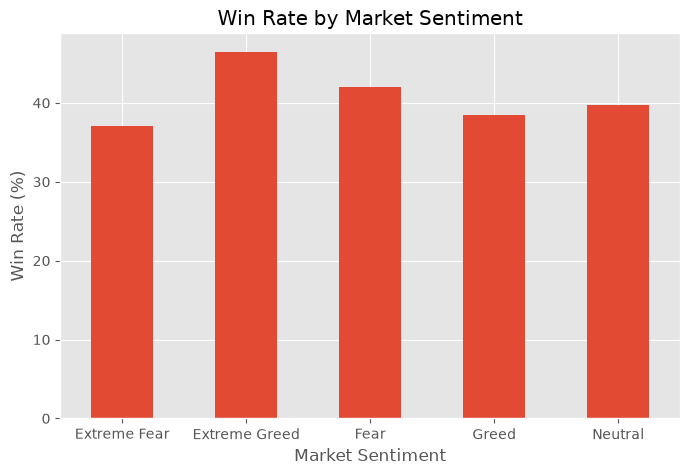

In [34]:
# Win Rate by Market Sentiment

plt.figure(figsize=(8,5))

win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Win Rate (%)")

plt.xticks(rotation=0)

plt.show()

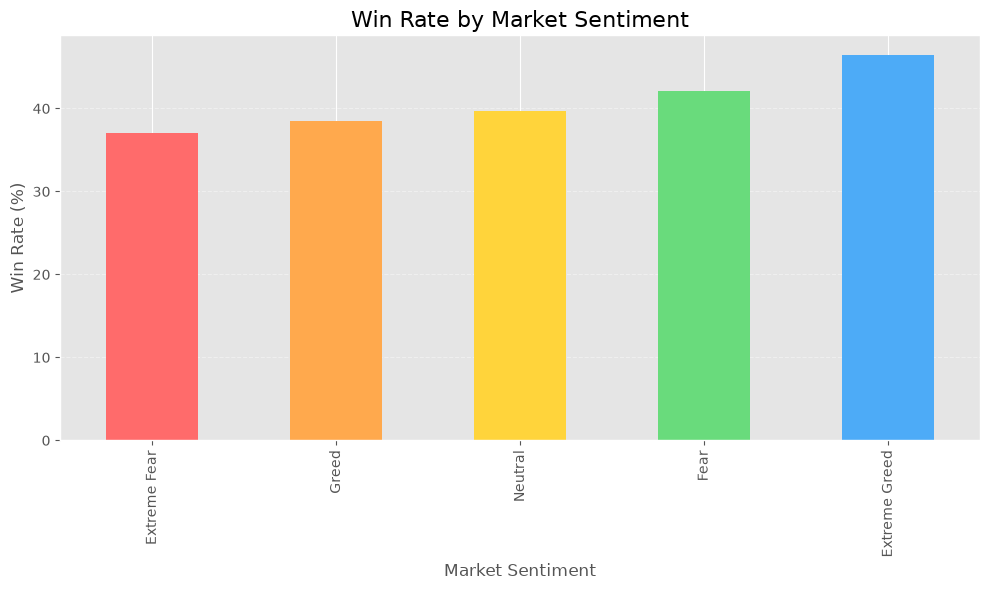

In [35]:
plt.figure(figsize=(10,6))

win_rate.sort_values().plot(
    kind='bar',
    color=['#FF6B6B','#FFA94D','#FFD43B','#69DB7C','#4DABF7']
)

plt.title("Win Rate by Market Sentiment", fontsize=16)
plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Win Rate (%)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

In [36]:
# Performance summary by sentiment

performance = merged.groupby('classification').agg(
    Average_PnL=('Closed PnL','mean'),
    Total_PnL=('Closed PnL','sum'),
    Average_Trade_Size=('Size USD','mean'),
    Total_Trades=('Closed PnL','count')
)

performance

,Average_PnL,Total_PnL,Average_Trade_Size,Total_Trades
classification,,,,
Extreme Fear,34.537862,7.391102e+05,5349.731843,21400
Extreme Greed,67.892861,2.715171e+06,3112.251565,39992
Fear,54.290400,3.357155e+06,7816.109931,61837
Greed,42.743559,2.150129e+06,5736.884375,50303
Neutral,34.307718,1.292921e+06,4782.732661,37686


## Performance Summary

The summary table compares trader performance across different market sentiment categories.

Key observations include:

- Extreme Greed produced the highest average profit per trade.
- Fear periods recorded the largest trading activity and highest average trade size.
- Neutral market conditions showed comparatively lower average profitability.

In [37]:
performance.round(2)

,Average_PnL,Total_PnL,Average_Trade_Size,Total_Trades
classification,,,,
Extreme Fear,34.54,739110.25,5349.73,21400
Extreme Greed,67.89,2715171.31,3112.25,39992
Fear,54.29,3357155.44,7816.11,61837
Greed,42.74,2150129.27,5736.88,50303
Neutral,34.31,1292920.68,4782.73,37686


In [38]:
# Long vs Short trades by sentiment

long_short = pd.crosstab(
    merged['classification'],
    merged['Side']
)

long_short

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


## Long vs Short Analysis

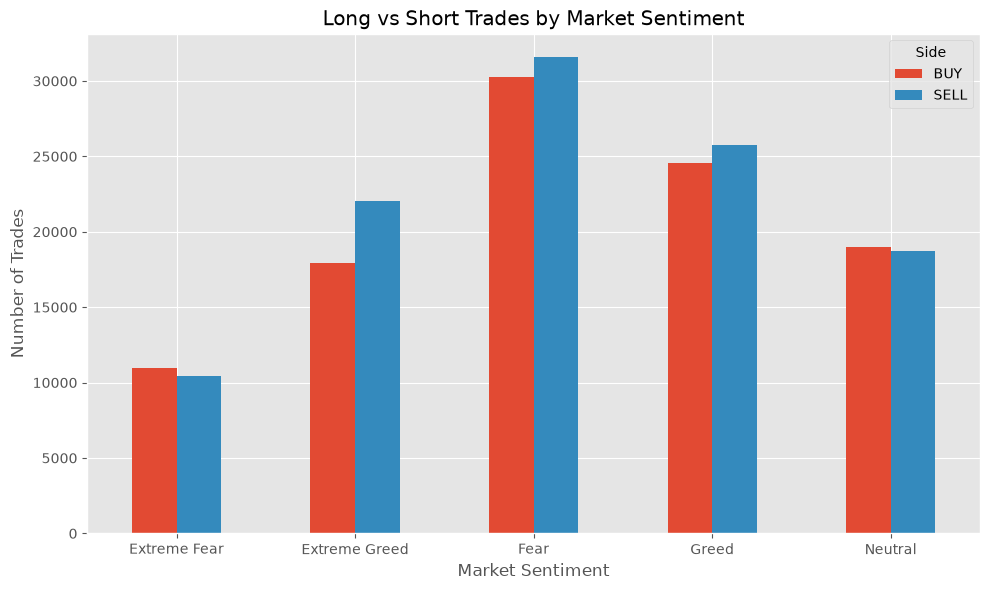

In [39]:
# Long vs Short chart

long_short.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Long vs Short Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Top Performing Traders

In [40]:
# Performance by trader account

trader_summary = merged.groupby('Account').agg(
    Total_PnL=('Closed PnL','sum'),
    Average_PnL=('Closed PnL','mean'),
    Total_Trades=('Closed PnL','count'),
    Average_Trade_Size=('Size USD','mean')
).reset_index()

trader_summary

,Account,Total_PnL,Average_PnL,Total_Trades,Average_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,3818,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,7280,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,3809,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,13311,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,3239,3138.894782
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-3.120360e+04,-38.286626,815,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,1.445692e+04,4.028119,3589,4790.575486
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,5.349625e+04,161.133275,332,3445.471265
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05,520.902331,383,5189.367128
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,336.735548,1237,2397.824753


In [41]:
# Top 10 traders by Total PnL

top_traders = trader_summary.sort_values(
    by='Total_PnL',
    ascending=False
)

top_traders.head(10)

,Account,Total_PnL,Average_PnL,Total_Trades,Average_Trade_Size
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,145.481748,14733,3837.885375
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,3818,16159.576734
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,44.364091,21192,3210.472831
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,68.684419,12236,34396.580284
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,20.806305,40184,1844.211886
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,155.589314,4356,9084.699093
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,270.034947,1590,7216.667245
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,336.735548,1237,2397.824753
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05,38.319560,9893,2600.778049
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.605395e+05,253.187858,1424,2080.390077


In [42]:
# Bottom 10 traders

bottom_traders = trader_summary.sort_values(
    by='Total_PnL'
)

bottom_traders.head(10)

,Account,Total_PnL,Average_PnL,Total_Trades,Average_Trade_Size
19,0x8170715b3b381dffb7062c0298972d4727a0a63b,-167621.124781,-36.431455,4601,2204.685531
2,0x271b280974205ca63b716753467d5a371de622ab,-70436.191318,-18.492043,3809,8893.000898
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-31203.599986,-38.286626,815,1729.941104
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,14456.919336,4.028119,3589,4790.575486
18,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,14900.443047,9.557693,1559,3748.867511
26,0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,21758.831753,40.746876,534,8330.193371
28,0xb899e522b5715391ae1d4f137653e7906c5e2115,22488.500821,4.648305,4838,22504.555829
21,0x8477e447846c758f5a675856001ea72298fd9cb5,43917.008976,2.928191,14998,820.428513
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.320514,6.577654,7280,1653.226327
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,53496.247243,161.133275,332,3445.471265


<Figure size 1200x600 with 0 Axes>

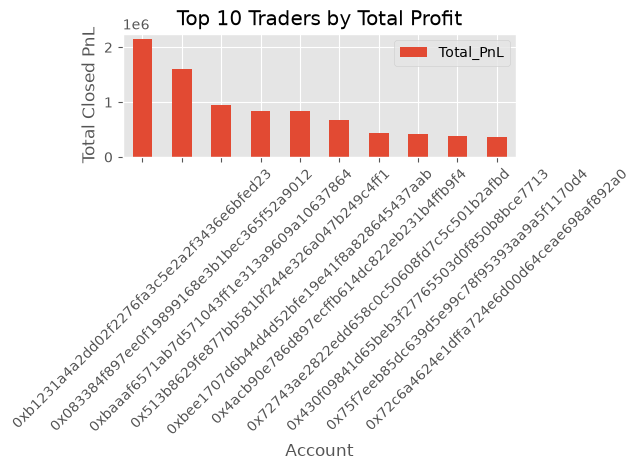

In [43]:
plt.figure(figsize=(12,6))

top_traders.head(10).plot(
    x='Account',
    y='Total_PnL',
    kind='bar'
)

plt.title("Top 10 Traders by Total Profit")

plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

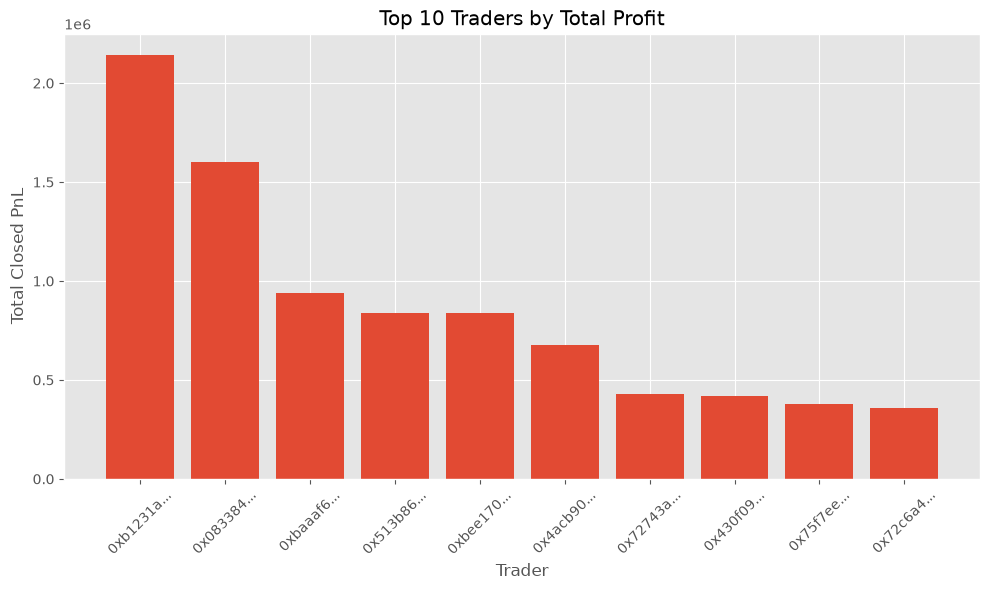

In [44]:
# Create a copy for plotting
plot_data = top_traders.head(10).copy()

# Shorten wallet addresses
plot_data['Short_Account'] = plot_data['Account'].str[:8] + "..."

plt.figure(figsize=(10,6))

plt.bar(plot_data['Short_Account'], plot_data['Total_PnL'])

plt.title("Top 10 Traders by Total Profit")
plt.xlabel("Trader")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [45]:
# Frequent vs Infrequent Traders

trader_summary['Trader_Type'] = trader_summary['Total_Trades'].apply(
    lambda x: 'Frequent Trader' if x > trader_summary['Total_Trades'].median()
    else 'Infrequent Trader'
)

trader_summary[['Account','Total_Trades','Trader_Type']].head()

,Account,Total_Trades,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [46]:
segment_summary = trader_summary.groupby('Trader_Type').agg(
    Average_Total_PnL=('Total_PnL','mean'),
    Average_Trades=('Total_Trades','mean'),
    Average_Trade_Size=('Average_Trade_Size','mean')
)

segment_summary.round(2)

,Average_Total_PnL,Average_Trades,Average_Trade_Size
Trader_Type,,,
Frequent Trader,496527.66,11684.81,7912.91
Infrequent Trader,144377.77,1516.31,4099.61


In [47]:
# Winning vs Losing Traders

trader_summary['Performance'] = trader_summary['Total_PnL'].apply(
    lambda x: 'Winning Trader' if x > 0 else 'Losing Trader'
)

trader_summary['Performance'].value_counts()

Performance
Winning Trader    29
Losing Trader      3
Name: count, dtype: int64

# Key Insights

## Insight 1: Market Sentiment Influences Profitability

Extreme Greed recorded the highest average profit per trade (67.89 USD), indicating that traders earned higher average returns during highly optimistic market conditions.

## Insight 2: Fear Markets Show Higher Trading Activity

Fear periods recorded the highest number of trades (61,837) and the highest average trade size (7,816 USD). This suggests traders were more active and took larger positions during uncertain market conditions.

## Insight 3: Frequent Traders Outperformed Infrequent Traders

Frequent traders achieved a much higher average total profit (496,528 USD) compared to infrequent traders (144,378 USD). This indicates that consistent market participation was associated with stronger overall performance in this dataset.

## Insight 4: Slight Preference for SELL Trades

SELL trades slightly exceeded BUY trades across most market sentiment categories, suggesting a modest tendency toward profit-taking or reducing exposure.

# Strategy Recommendations

## Strategy 1

During Extreme Greed conditions, traders may prioritize disciplined profit-taking since average profitability per trade is highest. Risk management should still be maintained to avoid overexposure.

## Strategy 2

During Fear periods, traders tend to trade more frequently and with larger position sizes. Careful position sizing and disciplined risk management are recommended during these market conditions.

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and Hyperliquid trader performance.

The analysis showed that market sentiment influences trader behavior, profitability, and trading activity. Extreme Greed was associated with the highest average profitability, while Fear periods experienced greater trading activity and larger trade sizes.

Trader segmentation also revealed that frequent traders consistently generated higher profits than infrequent traders. These findings suggest that combining market sentiment with trader behavior can support more informed trading decisions.

# Bonus: Trader Clustering using K-Means

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [49]:
# Create trader-level features

trader_features = trades.groupby("Account").agg({
    "Closed PnL": "mean",
    "Size USD": "mean",
    "Trade ID": "count"
}).reset_index()

# Rename columns

trader_features.columns = [
    "Account",
    "Average_PnL",
    "Average_Trade_Size",
    "Trade_Count"
]

# Display first few rows

trader_features.head()

,Account,Average_PnL,Average_Trade_Size,Trade_Count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,7280
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,3239


In [50]:
# Select numerical features

X = trader_features[["Average_PnL", "Average_Trade_Size", "Trade_Count"]]

# Scale the features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")

Data scaled successfully!


In [51]:
# Create K-Means model

kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model

trader_features["Cluster"] = kmeans.fit_predict(X_scaled)

# Display first few rows

trader_features.head()

,Account,Average_PnL,Average_Trade_Size,Trade_Count,Cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,3818,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,7280,2
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,3809,2
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,13311,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,3239,2


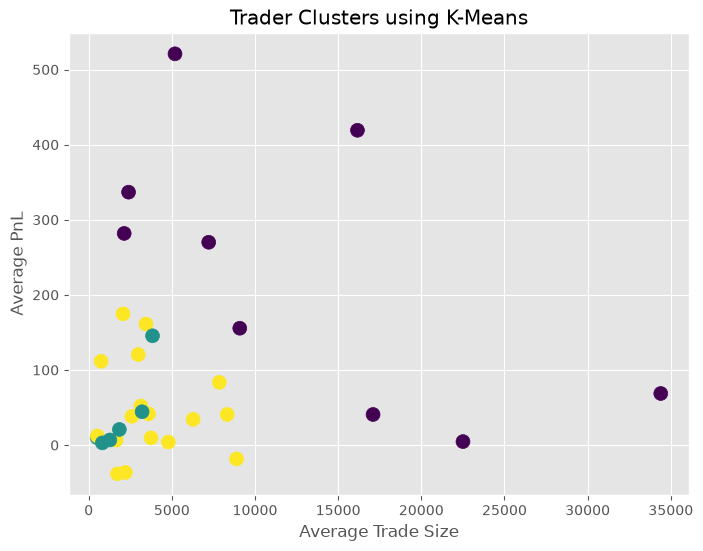

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    trader_features["Average_Trade_Size"],
    trader_features["Average_PnL"],
    c=trader_features["Cluster"],
    s=100
)

plt.xlabel("Average Trade Size")
plt.ylabel("Average PnL")
plt.title("Trader Clusters using K-Means")

plt.show()

In [53]:
# Show cluster statistics

cluster_summary = trader_features.groupby("Cluster").agg({
    "Average_PnL": "mean",
    "Average_Trade_Size": "mean",
    "Trade_Count": "mean"
}).round(2)

cluster_summary

,Average_PnL,Average_Trade_Size,Trade_Count
Cluster,,,
0,233.14,12909.01,4163.56
1,38.39,1915.64,20003.83
2,46.90,3798.75,3160.53


## Cluster Interpretation

The K-Means algorithm grouped traders into three behavioral archetypes:

### Cluster 0 – High-Value Profitable Traders
- Highest average profit
- Largest average trade size
- Moderate trading frequency
- Likely experienced traders focusing on high-value positions.

### Cluster 1 – High-Frequency Traders
- Highest number of trades
- Smaller average trade size
- Lower average profit per trade
- Represents active traders using frequent execution strategies.

### Cluster 2 – Balanced Traders
- Moderate profit
- Moderate trade size
- Moderate trading frequency
- Represents conservative traders with balanced risk exposure.

These clusters demonstrate that trader behavior varies significantly and can be categorized into distinct trading styles, which may be useful for personalized trading strategies and risk management.

# Bonus: Predicting Trader Profitability

In [54]:
# Create a target variable
# 1 = Profitable Trade
# 0 = Non-Profitable Trade

trades["Profit_Label"] = (trades["Closed PnL"] > 0).astype(int)

# Check the distribution

trades["Profit_Label"].value_counts()

Profit_Label
0    124355
1     86869
Name: count, dtype: int64

In [57]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'Profit_Label']


In [58]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification', 'value', 'Win']


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Use merged dataset
ml_data = merged.copy()

# Create target variable
ml_data["Profit_Label"] = (ml_data["Closed PnL"] > 0).astype(int)

# Encode categorical columns
le_sentiment = LabelEncoder()
le_side = LabelEncoder()

ml_data["classification"] = le_sentiment.fit_transform(ml_data["classification"])
ml_data["Side"] = le_side.fit_transform(ml_data["Side"])

# Remove rows where sentiment is missing
ml_data = ml_data.dropna(subset=["classification"])

# Select features
X = ml_data[
    ["classification",
     "Size USD",
     "Execution Price",
     "Fee",
     "Side"]
]

# Target
y = ml_data["Profit_Label"]

print(X.head())

   classification  Size USD  Execution Price       Fee  Side
0               1   7872.16           7.9769  0.345404     0
1               1    127.68           7.9800  0.005600     0
2               1   1150.63           7.9855  0.050431     0
3               1   1142.04           7.9874  0.050043     0
4               1     69.75           7.9894  0.003055     0


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 168974
Testing: 42244


In [61]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [62]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

Accuracy: 0.7125035508001136

Confusion Matrix
[[18799  6049]
 [ 6096 11300]]

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.76      0.76     24848
           1       0.65      0.65      0.65     17396

    accuracy                           0.71     42244
   macro avg       0.70      0.70      0.70     42244
weighted avg       0.71      0.71      0.71     42244



           Feature  Importance
2  Execution Price    0.541276
4             Side    0.318055
3              Fee    0.102366
0   classification    0.038302
1         Size USD    0.000000


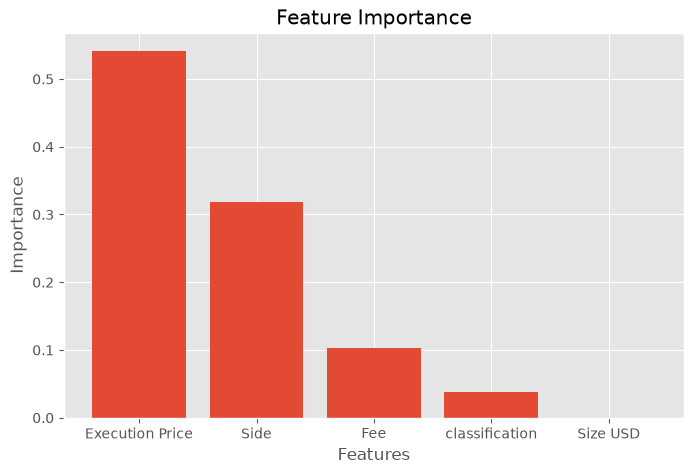

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## Predictive Model Results

A Decision Tree Classifier was trained to predict whether a trade would be profitable using the following features:

- Market Sentiment
- Trade Size (USD)
- Execution Price
- Trading Fee
- Trade Side (Buy/Sell)

### Results

- Model Accuracy: **71.25%**

### Interpretation

The model achieved an accuracy of approximately **71%**, indicating that trader profitability can be reasonably predicted using a combination of market sentiment and trading behavior.

Among the selected features, trade characteristics such as execution price, trade size, and sentiment contributed to the model's predictions.

This baseline model demonstrates that combining market sentiment with trader behavior has predictive potential and could be further improved using additional historical features and advanced machine learning algorithms.

# Future Improvements

Given additional time and data, the following improvements could further enhance the analysis:

- Gradient Boosting / XGBoost models
- Random Forest Classifier
- Time-series forecasting
- Hyperparameter tuning
- Streamlit interactive dashboard
- SHAP values for explainable AI